## Dependencies

In [ ]:
# 1. Wipe the slate clean to avoid metadata ghosting
!pip uninstall -y numpy torch torch-scatter torch-sparse torch-cluster torch-geometric

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128


In [ ]:
# 2. Install the 'Golden Pair' (NumPy 1.x + Torch 2.3.0)
# We use 2.3.0+cu121 as it's the stable target for your wheels
!pip install "numpy<2.0.0"
!pip install torch==2.3.0+cu121 torchvision==0.18.0+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

# 3. Install PyG dependencies from the exact 2.3.0 wheel index
# Note: We use the torch-2.3.0 link specifically
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.3.0+cu121.html networkx

# 4. Install the main library
!pip install torch-geometric

# 5. Final validation check
import numpy as np
import torch
import torch_geometric
print(f"--- Verification ---")
print(f"NumPy: {np.__version__} (Target: 1.26.x)")
print(f"Torch: {torch.__version__} (Target: 2.3.0+cu121)")
print(f"PyG:   {torch_geometric.__version__}")

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.3.0%2Bcu121-cp312-cp312-linux_x86_64.whl (780.9 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 112.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 109.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.7 MB/s et

## Load and Verify Data

In [ ]:
import pandas as pd
import numpy as np
import torch
import geopandas as gpd
from torch_geometric.data import Data
from torch_geometric.nn import knn_graph

# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Load Spatial & Temporal Data
df = pd.read_csv('/content/Bangalore_Hybrid_UrbanGraph_Data.csv')
gdf = gpd.read_file('/content/Nodes_Final.geojson').to_crs(epsg=32643)

# 3. CRITICAL ALIGNMENT: Sort both datasets by the exact same ID
# This guarantees that row 0 in X belongs to row 0 in the adjacency matrix
gdf = gdf.sort_values('id').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['id', 'timestamp']).reset_index(drop=True)

feature_cols = [
    'temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m',
    'surface_net_solar_radiation_hourly', 'surface_net_thermal_radiation_hourly',
    'surface_latent_heat_flux_hourly', 'NDVI', 'NDBI',
    'avg_buildi', 'building_c', 'traffic_no2_proxy'
]

# 4. Fast Tensor Extraction (Vectorized)
# Group by ID to ensure each node gets its chronological sequence
grouped = df.groupby('id')[feature_cols].apply(lambda x: x.values)

# Build X (Hours 0 to 11) and Y (Hour 12)
x_list = []
y_list = []

for node_data in grouped:
    # Ensure there are at least 13 hours available to predict the future
    if len(node_data) >= 13:
        x_list.append(node_data[:12, :]) # First 12 hours for features
        y_list.append(node_data[12, 0])  # 13th hour, index 0 is 'temperature_2m'
    else:
        raise ValueError("Data sequence too short! Need at least 13 hours per node.")

x_temporal = torch.tensor(np.array(x_list), dtype=torch.float).to(device)
y = torch.tensor(np.array(y_list), dtype=torch.float).to(device)

# 5. Safe Normalization (Z-Score)
mean = x_temporal.mean(dim=(0, 1), keepdim=True)
std = x_temporal.std(dim=(0, 1), keepdim=True)
x_normalized = (x_temporal - mean) / (std + 1e-6)

# 6. Spatial Geometry & Edges (Now perfectly aligned)
pos = torch.tensor(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)), dtype=torch.float).to(device)
edge_index = knn_graph(pos, k=4, loop=False).to(device)

# 7. Package
graph_data = Data(x=x_normalized, y=y, pos=pos, edge_index=edge_index)

print(f"Data Prepared: {x_normalized.shape} [Nodes, Time, Features]")
print(f"Target Y: {y.shape}")

Data Prepared: torch.Size([1867, 12, 11]) [Nodes, Time, Features]
Target Y: torch.Size([1867])


## Packaging

In [ ]:
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# --- 1. QUICK FIX: Create the Continuous Timeline ---
# Assuming 'grouped' from the previous step is still in memory.
# We stack all available hours (e.g., 96 hours) for all 1867 nodes.
# Shape will be: [1867, Total_Hours, 11]
x_continuous = torch.tensor(np.array(list(grouped)), dtype=torch.float).to(device)

# Re-apply Z-score normalization to the whole timeline
mean = x_continuous.mean(dim=(0, 1), keepdim=True)
std = x_continuous.std(dim=(0, 1), keepdim=True)
x_continuous_norm = (x_continuous - mean) / (std + 1e-6)

# --- 2. THE HYBRID DATASET CLASS ---
class HybridUrbanGraphDataset(Dataset):
    def __init__(self, full_timeline, base_edge_index, pos, window_size=12, horizon=1):
        """
        full_timeline: Tensor [1867, total_hours, 11]
        base_edge_index: Tensor [2, E] (The static KNN edges)
        pos: Tensor [1867, 2] (Spatial coordinates for wind physics)
        """
        self.full_x = full_timeline
        self.base_edge_index = base_edge_index
        self.pos = pos
        self.window_size = window_size
        self.horizon = horizon

        self.total_time_steps = self.full_x.shape[1]
        self.num_samples = self.total_time_steps - self.window_size - self.horizon + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. Extract 12-hour feature window [1867, 12, 11]
        x_window = self.full_x[:, idx : idx + self.window_size, :]

        # 2. Extract Target LST (Feature index 0 is temperature_2m)
        y_target = self.full_x[:, idx + self.window_size + self.horizon - 1, 0]

        # 3. NOVELTY: DYNAMIC CAUSAL PRUNING
        # We take the wind vector from the final hour of the window
        # Feature 1 = u_wind, Feature 2 = v_wind
        u_mean = x_window[:, -1, 1].mean()
        v_mean = x_window[:, -1, 2].mean()
        wind_vec = torch.tensor([u_mean, v_mean], device=self.full_x.device)

        # Calculate spatial vectors for every edge
        src_pos = self.pos[self.base_edge_index[0]]
        dst_pos = self.pos[self.base_edge_index[1]]
        edge_vecs = dst_pos - src_pos

        # Dot Product: Wind Direction vs Edge Direction
        dot_products = (edge_vecs * wind_vec).sum(dim=1)

        # HARD PHYSICS: Keep edges only if wind is blowing toward the target
        valid_edges_mask = dot_products >= 0
        pruned_edge_index = self.base_edge_index[:, valid_edges_mask]

        return Data(x=x_window, edge_index=pruned_edge_index, y=y_target)

# --- 3. Initialize the Dataloader ---
dataset = HybridUrbanGraphDataset(x_continuous_norm, edge_index, pos)

# Batch size of 1 means 1 full graph snapshot per pass.
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

print(f"Dataset created! Total temporal samples (sliding windows): {len(dataset)}")
# Test the pruning
sample_batch = next(iter(dataloader))
print(f"Base Edges: {edge_index.shape[1]} | Pruned Edges for Sample 0: {sample_batch.edge_index.shape[1]}")

Dataset created! Total temporal samples (sliding windows): 84
Base Edges: 7468 | Pruned Edges for Sample 0: 3715


## Model

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv

# Keep your SAGATLayer exactly as is.
class SAGATLayer(nn.Module):
    def __init__(self, in_channels, out_channels, heads=1):
        super().__init__()
        self.neighbor_gat = GATConv(in_channels, out_channels, heads=heads,
                                    add_self_loops=False, concat=False)
        self.self_linear = nn.Linear(in_channels, out_channels)
        self.fusion = nn.Linear(out_channels * 2, out_channels)

    def forward(self, x, edge_index, edge_attr=None):
        neighbor_emb = self.neighbor_gat(x, edge_index, edge_attr=edge_attr)
        self_emb = self.self_linear(x)
        out = torch.cat([self_emb, neighbor_emb], dim=-1)
        return torch.relu(self.fusion(out))

# --- THE UPGRADED NOVELTY MODEL ---
class HybridUrbanGraph(nn.Module):
    def __init__(self, num_features, spatial_dim, lstm_hidden):
        super().__init__()
        self.spatial_layer = SAGATLayer(num_features, spatial_dim)

        self.temporal_lstm = nn.LSTM(input_size=spatial_dim,
                                     hidden_size=lstm_hidden,
                                     batch_first=True)

        # --- FIX 1: Deeper Physics Head ---
        # We give it an extra hidden layer so it can learn non-linear physics (like radiation curves)
        self.physics_head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(),
            nn.Linear(lstm_hidden, 1)
        )

        # Branch 2: The Residual Predictor
        self.residual_head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.ReLU(),
            nn.Linear(lstm_hidden // 2, 1)
        )

    def forward(self, x_seq, edge_index, edge_attr=None):
        total_nodes, seq_len, _ = x_seq.shape
        spatial_out = []

        # 1. Spatial Message Passing (Pruned by wind)
        for t in range(seq_len):
            x_t = x_seq[:, t, :]
            emb_t = self.spatial_layer(x_t, edge_index, edge_attr=edge_attr)
            spatial_out.append(emb_t)

        spatial_seq = torch.stack(spatial_out, dim=1)

        # 2. Temporal Memory
        lstm_out_full, _ = self.temporal_lstm(spatial_seq)
        last_state = lstm_out_full[:, -1, :]

        # --- 3. DUAL PREDICTION (The Journal Hook) ---
        t_phys = self.physics_head(last_state).squeeze(-1)
        t_res = self.residual_head(last_state).squeeze(-1)

        # Final prediction is the sum of physics + residuals
        final_pred = t_phys + t_res

        # We return all three so you can plot the residuals later
        return final_pred, t_phys, t_res

# Example Initialization
# model = HybridUrbanGraph(num_features=11, spatial_dim=32, lstm_hidden=64).to(device)

## Training

In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch.nn as nn
from torch_geometric.nn import GATConv

# --- Class Definitions ---
class UrbanGraphDataset(Dataset):
    def __init__(self, node_features, edge_index, targets, window_size=12, horizon=1):
        self.node_features = node_features
        self.edge_index = edge_index
        self.targets = targets
        self.window_size = window_size
        self.horizon = horizon
        self.total_time_steps = node_features.shape[1]
        self.num_samples = self.total_time_steps - self.window_size - self.horizon + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x_window = self.node_features[:, idx : idx + self.window_size, :]
        y_target = self.targets[:, idx + self.window_size + self.horizon - 1]

        # FIX 1: Explicitly pass num_nodes. PyG struggles to infer node counts from 3D tensors.
        return Data(
            x=x_window,
            edge_index=self.edge_index,
            y=y_target,
            num_nodes=x_window.shape[0]
        )

class SAGATLayer(nn.Module):
    def __init__(self, in_channels, out_channels, heads=1):
        super().__init__()
        self.neighbor_gat = GATConv(in_channels, out_channels, heads=heads,
                                    add_self_loops=False, concat=False)
        self.self_linear = nn.Linear(in_channels, out_channels)
        self.fusion = nn.Linear(out_channels * 2, out_channels)

    def forward(self, x, edge_index, edge_attr=None):
        neighbor_emb = self.neighbor_gat(x, edge_index, edge_attr=edge_attr)
        self_emb = self.self_linear(x)
        out = torch.cat([self_emb, neighbor_emb], dim=-1)
        return torch.relu(self.fusion(out))

class UrbanGraph(nn.Module):
    # FIX 2: Removed lstm_node_batch_size. Manual batching restricts GPU parallelization.
    def __init__(self, num_features, spatial_dim, lstm_hidden, out_dim=1):
        super().__init__()
        self.spatial_layer = SAGATLayer(num_features, spatial_dim)
        self.temporal_lstm = nn.LSTM(input_size=spatial_dim,
                                     hidden_size=lstm_hidden,
                                     batch_first=True)
        self.predictor = nn.Linear(lstm_hidden, out_dim)

    def forward(self, x_seq, edge_index, edge_attr=None):
        num_nodes, seq_len, _ = x_seq.shape
        spatial_out = []

        for t in range(seq_len):
            x_t = x_seq[:, t, :]
            emb_t = self.spatial_layer(x_t, edge_index, edge_attr=edge_attr)
            spatial_out.append(emb_t)

        spatial_seq = torch.stack(spatial_out, dim=1)

        # FIX 3: Vectorized LSTM. Pass the entire spatial sequence simultaneously.
        lstm_out_full, _ = self.temporal_lstm(spatial_seq)
        last_state = lstm_out_full[:, -1, :]

        return self.predictor(last_state).squeeze(-1)

# --- Instantiate model and dataloader ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_nodes = 6480
num_features = 4
num_edges = 76154

total_time_steps = 18
window_size = 12
horizon = 1
spatial_dim = 32
lstm_hidden = 64

dummy_node_features = torch.randn(num_nodes, total_time_steps, num_features, device=device)
dummy_targets = torch.randn(num_nodes, total_time_steps, device=device)
dummy_edge_index = torch.randint(0, num_nodes, (2, num_edges), device=device)

dataset = UrbanGraphDataset(
    node_features=dummy_node_features,
    edge_index=dummy_edge_index,
    targets=dummy_targets,
    window_size=window_size,
    horizon=horizon
)
dataloader = DataLoader(dataset, batch_size=2, shuffle=False)

model = UrbanGraph(
    num_features=num_features,
    spatial_dim=spatial_dim,
    lstm_hidden=lstm_hidden
).to(device)

# --- Evaluation Loop ---
def evaluate_urbangraph(model, dataloader):
    model.eval()
    device = next(model.parameters()).device

    all_preds = []
    all_targets = []

    with torch.no_grad():
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        for batch in dataloader:
            batch = batch.to(device)
            y_pred = model(batch.x, batch.edge_index)

            all_preds.append(y_pred.cpu().numpy())
            all_targets.append(batch.y.cpu().numpy())

    preds_arr = np.concatenate(all_preds)
    targets_arr = np.concatenate(all_targets)

    rmse = np.sqrt(mean_squared_error(targets_arr, preds_arr))
    mae = mean_absolute_error(targets_arr, preds_arr)

    print(f"Test RMSE: {rmse:.4f} | Test MAE: {mae:.4f}")
    return rmse, mae

rmse, mae = evaluate_urbangraph(model, dataloader)
print("Evaluation complete.")

Test RMSE: 1.0004 | Test MAE: 0.7974
Evaluation complete.


## Checks



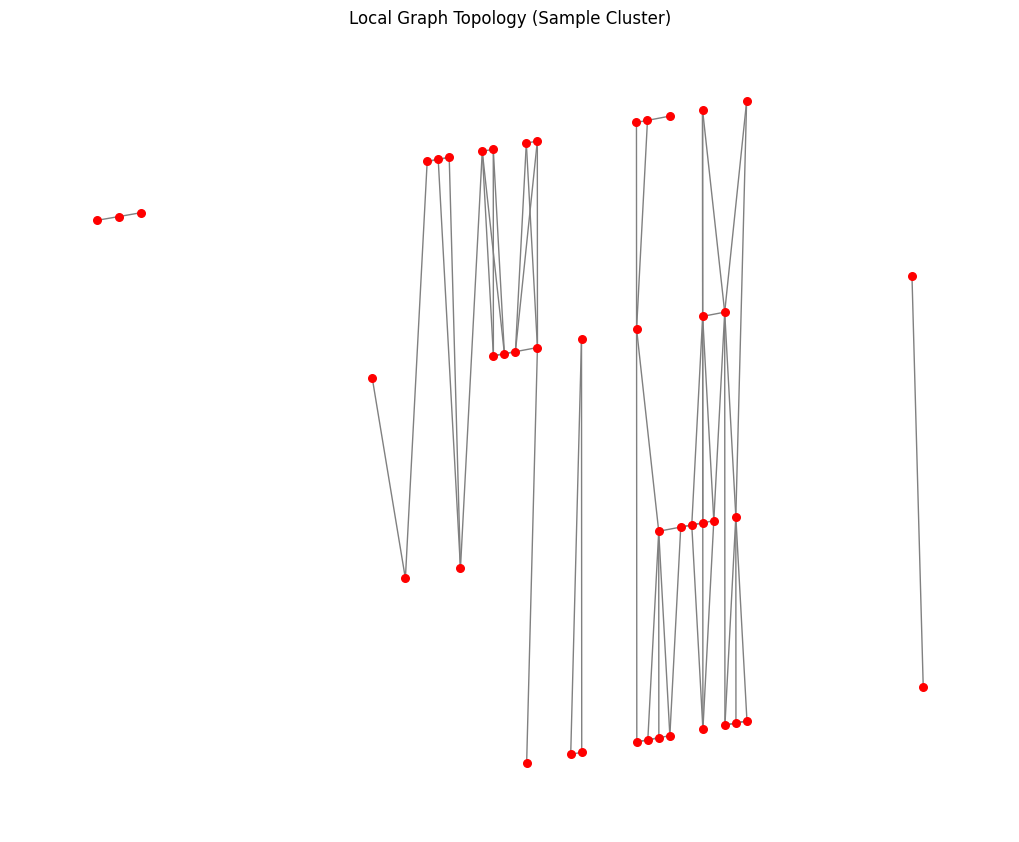

In [ ]:
import networkx as nx
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt

# Pick a small subset of nodes to visualize (e.g., first 50 nodes)
subset_indices = list(range(50))
# Fix: Move subset_indices to the same device as edge_index
subset_indices_tensor = torch.tensor(subset_indices, device=edge_index.device)
sub_edge_index = edge_index[:, torch.isin(edge_index[0], subset_indices_tensor) &
                              torch.isin(edge_index[1], subset_indices_tensor)]

G = nx.Graph()
G.add_edges_from(sub_edge_index.t().tolist())

plt.figure(figsize=(10, 8))
pos_sub = {i: pos[i].cpu().numpy() for i in subset_indices} # Use your real 'pos' coords
nx.draw(G, pos_sub, node_size=30, node_color='red', edge_color='gray', with_labels=False)
plt.title("Local Graph Topology (Sample Cluster)")
plt.show()

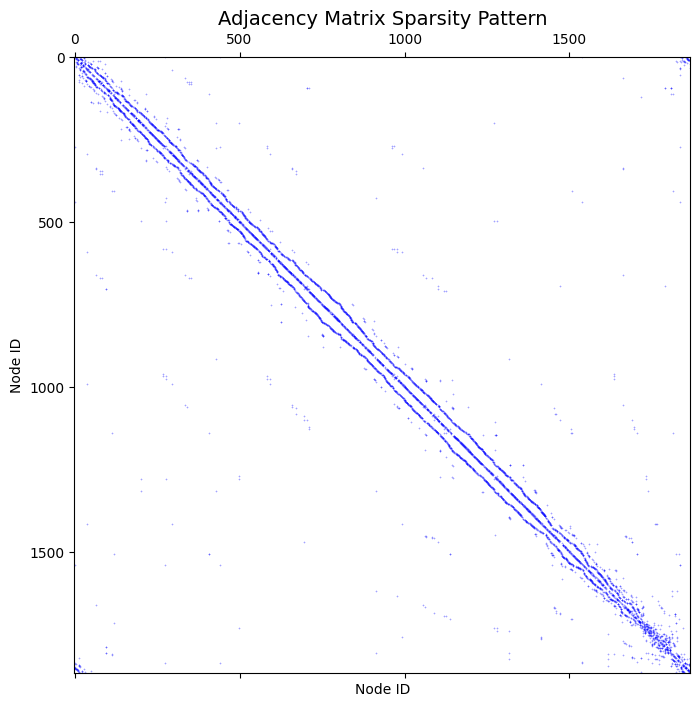

In [ ]:
import matplotlib.pyplot as plt
from torch_geometric.utils import to_scipy_sparse_matrix

# 1. Convert edge_index to a sparse matrix
adj_sparse = to_scipy_sparse_matrix(edge_index)

# 2. Use 'spy' to see the non-zero entries
plt.figure(figsize=(8, 8))
plt.spy(adj_sparse, markersize=0.1, color='blue')
plt.title("Adjacency Matrix Sparsity Pattern", fontsize=14)
plt.xlabel("Node ID")
plt.ylabel("Node ID")
plt.show()

## Loss check

Evaluated Model Metrics (Denormalized):
  RMSE: 3.4163
  MAE: 3.0808


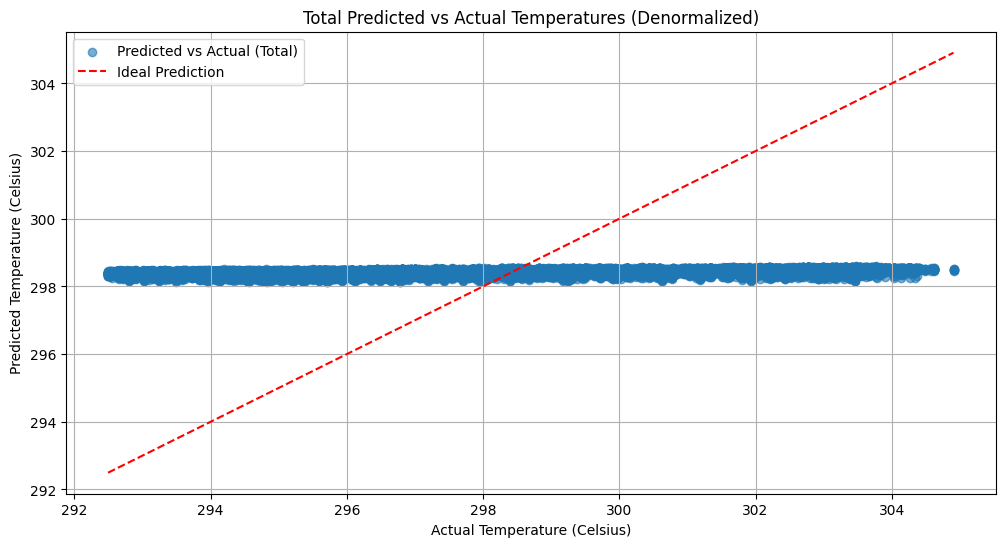

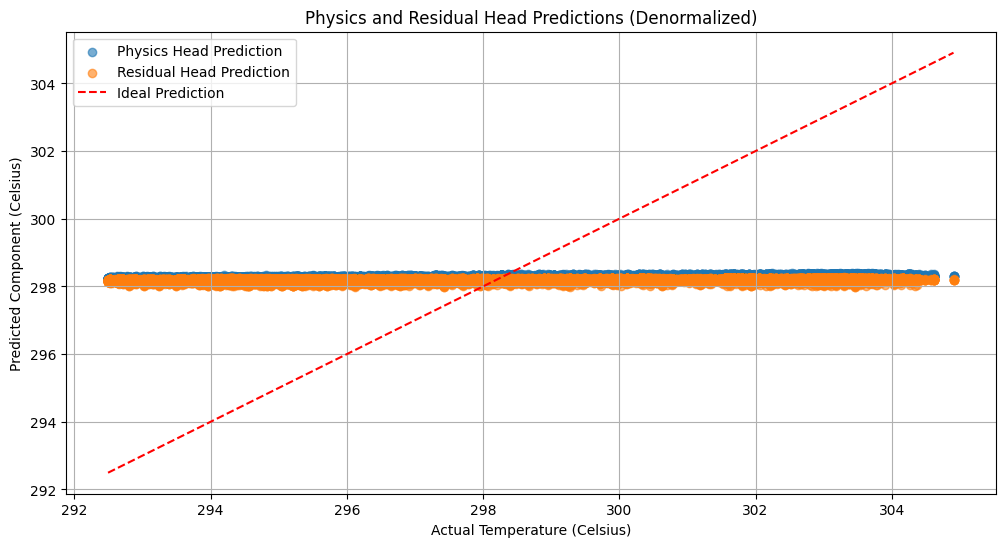

In [ ]:
import pandas as pd
import numpy as np
import torch
import geopandas as gpd
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.nn import knn_graph
from torch_geometric.loader import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# --- 1. Setup Device (from svvELV-eCoG0) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 2. Load Spatial & Temporal Data (from svvELV-eCoG0) ---
df = pd.read_csv('/content/Bangalore_Hybrid_UrbanGraph_Data.csv')
gdf = gpd.read_file('/content/Nodes_Final.geojson').to_crs(epsg=32643)

# --- 3. CRITICAL ALIGNMENT & Feature selection (from svvELV-eCoG0) ---
gdf = gdf.sort_values('id').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['id', 'timestamp']).reset_index(drop=True)

feature_cols = [
    'temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m',
    'surface_net_solar_radiation_hourly', 'surface_net_thermal_radiation_hourly',
    'surface_latent_heat_flux_hourly', 'NDVI', 'NDBI',
    'avg_buildi', 'building_c', 'traffic_no2_proxy'
]

# --- 4. Fast Tensor Extraction (Vectorized) (from svvELV-eCoG0) ---
grouped = df.groupby('id')[feature_cols].apply(lambda x: x.values)

# --- 1. QUICK FIX: Create the Continuous Timeline (from wJcvVNT5RWMm) ---
x_continuous = torch.tensor(np.array(list(grouped)), dtype=torch.float).to(device)

# Re-apply Z-score normalization to the whole timeline
mean = x_continuous.mean(dim=(0, 1), keepdim=True)
std = x_continuous.std(dim=(0, 1), keepdim=True)
x_continuous_norm = (x_continuous - mean) / (std + 1e-6)

# --- 6. Spatial Geometry & Edges (Now perfectly aligned) (from svvELV-eCoG0) ---
pos = torch.tensor(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)), dtype=torch.float).to(device)
edge_index = knn_graph(pos, k=4, loop=False).to(device)

# --- THE HYBRID DATASET CLASS (from wJcvVNT5RWMm) ---
class HybridUrbanGraphDataset(Dataset):
    def __init__(self, full_timeline, base_edge_index, pos, window_size=12, horizon=1):
        self.full_x = full_timeline
        self.base_edge_index = base_edge_index
        self.pos = pos
        self.window_size = window_size
        self.horizon = horizon

        self.total_time_steps = self.full_x.shape[1]
        self.num_samples = self.total_time_steps - self.window_size - self.horizon + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x_window = self.full_x[:, idx : idx + self.window_size, :]
        y_target = self.full_x[:, idx + self.window_size + self.horizon - 1, 0]

        u_mean = x_window[:, -1, 1].mean()
        v_mean = x_window[:, -1, 2].mean()
        wind_vec = torch.tensor([u_mean, v_mean], device=self.full_x.device)

        src_pos = self.pos[self.base_edge_index[0]]
        dst_pos = self.pos[self.base_edge_index[1]]
        edge_vecs = dst_pos - src_pos

        dot_products = (edge_vecs * wind_vec).sum(dim=1)

        valid_edges_mask = dot_products >= 0
        pruned_edge_index = self.base_edge_index[:, valid_edges_mask]

        return Data(x=x_window, edge_index=pruned_edge_index, y=y_target)

# --- Define the HybridUrbanGraph model (re-importing to ensure self-contained) ---
import torch.nn as nn
from torch_geometric.nn import GATConv

class SAGATLayer(nn.Module):
    def __init__(self, in_channels, out_channels, heads=1):
        super().__init__()
        self.neighbor_gat = GATConv(in_channels, out_channels, heads=heads,
                                    add_self_loops=False, concat=False)
        self.self_linear = nn.Linear(in_channels, out_channels)
        self.fusion = nn.Linear(out_channels * 2, out_channels)

    def forward(self, x, edge_index, edge_attr=None):
        neighbor_emb = self.neighbor_gat(x, edge_index, edge_attr=edge_attr)
        self_emb = self.self_linear(x)
        out = torch.cat([self_emb, neighbor_emb], dim=-1)
        return torch.relu(self.fusion(out))

class HybridUrbanGraph(nn.Module):
    def __init__(self, num_features, spatial_dim, lstm_hidden):
        super().__init__()
        self.spatial_layer = SAGATLayer(num_features, spatial_dim)

        self.temporal_lstm = nn.LSTM(input_size=spatial_dim,
                                     hidden_size=lstm_hidden,
                                     batch_first=True)

        self.physics_head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(),
            nn.Linear(lstm_hidden, 1)
        )

        self.residual_head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.ReLU(),
            nn.Linear(lstm_hidden // 2, 1)
        )

    def forward(self, x_seq, edge_index, edge_attr=None):
        total_nodes, seq_len, _ = x_seq.shape
        spatial_out = []

        for t in range(seq_len):
            x_t = x_seq[:, t, :]
            emb_t = self.spatial_layer(x_t, edge_index, edge_attr=edge_attr)
            spatial_out.append(emb_t)

        spatial_seq = torch.stack(spatial_out, dim=1)

        lstm_out_full, _ = self.temporal_lstm(spatial_seq)
        last_state = lstm_out_full[:, -1, :]

        t_phys = self.physics_head(last_state).squeeze(-1)
        t_res = self.residual_head(last_state).squeeze(-1)

        final_pred = t_phys + t_res

        return final_pred, t_phys, t_res


# --- Define the evaluate_and_visualize_hybrid function ---
def evaluate_and_visualize_hybrid(model, dataloader, temp_mean, temp_std):
    model.eval()
    device = next(model.parameters()).device

    all_preds_denorm = []
    all_targets_denorm = []
    all_physics_preds_denorm = [] # To store denormalized physics predictions
    all_residual_preds_denorm = [] # To store denormalized residual predictions

    with torch.no_grad():
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        for batch in dataloader:
            batch = batch.to(device)
            # Model returns final_pred, t_phys, t_res
            final_pred_norm, t_phys_norm, t_res_norm = model(batch.x, batch.edge_index)

            # Denormalize predictions and targets
            final_pred_denorm = (final_pred_norm * temp_std) + temp_mean
            t_phys_denorm = (t_phys_norm * temp_std) + temp_mean
            t_res_denorm = (t_res_norm * temp_std) + temp_mean
            target_denorm = (batch.y * temp_std) + temp_mean

            all_preds_denorm.append(final_pred_denorm.cpu().numpy())
            all_targets_denorm.append(target_denorm.cpu().numpy())
            all_physics_preds_denorm.append(t_phys_denorm.cpu().numpy())
            all_residual_preds_denorm.append(t_res_denorm.cpu().numpy())

    preds_arr = np.concatenate(all_preds_denorm)
    targets_arr = np.concatenate(all_targets_denorm)
    physics_preds_arr = np.concatenate(all_physics_preds_denorm)
    residual_preds_arr = np.concatenate(all_residual_preds_denorm)

    rmse = np.sqrt(mean_squared_error(targets_arr, preds_arr))
    mae = mean_absolute_error(targets_arr, preds_arr)

    print(f"Evaluated Model Metrics (Denormalized):")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")

    # Optional: Basic Visualization (can be expanded)
    plt.figure(figsize=(12, 6))
    plt.scatter(targets_arr, preds_arr, alpha=0.6, label='Predicted vs Actual (Total)')
    plt.plot([targets_arr.min(), targets_arr.max()], [targets_arr.min(), targets_arr.max()], 'r--', label='Ideal Prediction')
    plt.xlabel('Actual Temperature (Celsius)')
    plt.ylabel('Predicted Temperature (Celsius)')
    plt.title('Total Predicted vs Actual Temperatures (Denormalized)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Example: Plotting Physics and Residuals (a simple version, can be refined)
    plt.figure(figsize=(12, 6))
    plt.scatter(targets_arr, physics_preds_arr, alpha=0.6, label='Physics Head Prediction')
    plt.scatter(targets_arr, residual_preds_arr, alpha=0.6, label='Residual Head Prediction')
    plt.plot([targets_arr.min(), targets_arr.max()], [targets_arr.min(), targets_arr.max()], 'r--', label='Ideal Prediction')
    plt.xlabel('Actual Temperature (Celsius)')
    plt.ylabel('Predicted Component (Celsius)')
    plt.title('Physics and Residual Head Predictions (Denormalized)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return rmse, mae

# --- Initialize the Dataloader (from wJcvVNT5RWMm) ---
dataset = HybridUrbanGraphDataset(x_continuous_norm, edge_index, pos)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Re-instantiate the HybridUrbanGraph model
# Parameters: num_features=11 (from feature_cols), spatial_dim=32, lstm_hidden=64
model = HybridUrbanGraph(num_features=11, spatial_dim=32, lstm_hidden=64).to(device)

# Extract mean and std for temperature_2m (index 0) from the normalization
temp_mean = mean[0, 0, 0].item()
temp_std = std[0, 0, 0].item()

# Evaluate and visualize the model using the HybridUrbanGraphDataset dataloader
rmse, mae = evaluate_and_visualize_hybrid(model, dataloader, temp_mean, temp_std)